In [466]:
import sys
import os
sys.path.append(os.path.abspath(os.pardir))
from copy import deepcopy
from typing import Literal

import numpy as np
import pandas as pd
import sklearn.preprocessing as pre
from sklearn.pipeline import make_pipeline
from sklearn.cluster import KMeans

from processors import temparature, season, month
from transforming import (
    Apply, Calc, Fill, Group, KeepDataframe, Lag, Select, Swap,
    TypeRecast, WithSelected,
    boruta
)

# modeling dependencies
# from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import ConfusionMatrixDisplay, f1_score, roc_auc_score
import matplotlib.pyplot as plt


import uuid


def checkup(estimator, X, y, folds=7):
    metrics = []
    kf = StratifiedKFold(n_splits=folds, shuffle=True, random_state=19)
    for f, (train, valid) in enumerate(kf.split(X, y)):
        estimator.fit(X.loc[train], y[train])

        pt = estimator.predict_proba(X.loc[train]).T[1]
        pv = estimator.predict_proba(X.loc[valid]).T[1]

        auc_train = roc_auc_score(y[train], pt)
        auc_valid = roc_auc_score(y[valid], pv)
        f1_train = f1_score(y[train], pt > 0.5)
        f1_valid = f1_score(y[valid], pv > 0.5)
        metrics.append((auc_train, f1_train, auc_valid, f1_valid))
        print(f'Fold: {f}; TRAIN ROC AUC={auc_train:.5f}; TRAIN f1={f1_train:.5f} | VALID ROC AUC={auc_valid:.5f}; VALID f1={f1_valid:.5f}')
    means = np.mean(metrics, axis=0)
    print(f'MEAN: TRAIN ROC AUC={means[0]:.5f}; TRAIN f1={means[1]:.5f} | VALID ROC AUC={means[2]:.5f}; VALID f1={means[3]:.5f}')
    return estimator


df = pd.read_csv('data/train.csv', index_col='id')
test = pd.read_csv('data/test.csv', index_col='id')
test['rainfall'] = 0

__Pipelines__

In [2]:
ORIGIN = df.columns.to_list()
TEMPERATURES = ['mintemp', 'temparature', 'maxtemp']
MONTHS = [f'ct_month_{n}' for n in range(12)]
SEASONS = [f'ct_season_{n}' for n in range(4)]
ONE_HOTS = [*MONTHS, *SEASONS]


base_pipe = (
    # fix temperatures
    WithSelected(TEMPERATURES, prefix='')(
        Calc(lambda x: x.min(), to='_mintemp'),
        Calc(lambda x: x.max(), to='_maxtemp'),
        Calc(temparature, to='_temparature'),
        Select(TEMPERATURES, mode='drop'),
    ),
    Select(TEMPERATURES, mode='drop'),
    # abs dewpoint
    Calc('abs(dewpoint)', to='dewpoint'),
    # some simple features
    Calc('_maxtemp - _mintemp', 'tempdelta'),
    Calc('sunshine / _temparature', 'sunshine_div_temparature'),
    Calc('windspeed * winddirection', to='windspeed_mul_winddirection'),
    Calc('cloud * windspeed', to='cloud_mul_windspeed'),
    # Calc('cloud / humidity', to='cloud_div_humidity'),
    Calc('humidity * cloud', to='humidity_mul_cloud'),
    Calc('humidity * sunshine', to='humidity_mul_sunshine'),
    Calc('cloud / (sunshine + 1e-5)', to='cloud_div_sunshine'),
    Calc('sunshine / (sunshine + cloud)', to='sunshine_rate'),
    Calc('0.4 * humidity + 0.3 * cloud + 0.3 * sunshine', to='weather_index'),
    # Calc('0.4 * humidity + 0.3 * cloud + 0.3 * sunshine', to='weather_index'),

    # Calc('', to=''),
    Fill(0),

    # calc month one hots
    Calc(month, to='ct_month'),
    # WithSelected(['ct_month'])(
    #     pre.OneHotEncoder(),
    # ),
    # calc seasons one hots
    Calc(season, to='ct_season'),
    # WithSelected(['ct_season'])(
    #     pre.OneHotEncoder(),
    # ),

    # groupings
    # calc day-to-day mean rainfall
    # Group('day', {'rainfall': 'mean'}, prefix='day_to_day_mean_'),

    # statistic by day
    WithSelected(r'(?!ct_month|ct_season).*')(
        Group('day', 'mean', prefix='_day_mean_'),
    ),
    # statistic by month
    WithSelected(r'(?!day|ct_season).*')(
        Group('ct_month', 'mean', prefix='_month_mean_'),
    ),
    # # statistic by season
    # WithSelected(r'(?!day|ct_month_).*')(
    #     Group('ct_season', 'mean', prefix='season_mean_'),
    # ),

    # clusterize
    # WithSelected(lambda name: name not in TEMPERATURES)(
    #     Fill('mean'),
    #     Apply(
    #         estimator=KMeans(n_clusters=3, random_state=17),
    #         locpipe=pre.StandardScaler(),
    #         to='ct_kmeans_cluster',
    #     ),
    #     Select(['kmeans_cluster'], mode='keep'),
    # ),

    # add mean for last 3 days
    WithSelected(['pressure', 'humidity', 'cloud', 'sunshine'], prefix='last_3days_mean_')(
        Lag(3, 'mean'),
    ),
    # add for last day
    WithSelected(['pressure', 'humidity', 'cloud', 'sunshine'], prefix='last_1days_mean_')(
        Lag(1, 'mean'),
    ),
    # drop origin columns
    Select(ORIGIN, mode='drop'),
    # recast one hots to int
    WithSelected(r'(.*_\d+|ct_.*)$')(
        TypeRecast(int)
    ),
)
sgd_pipe = (
    *base_pipe,
    WithSelected(r'(?!ct|day).*$')(
        KeepDataframe(pre.StandardScaler()),
    )
)
pipes = {
    'base': make_pipeline(*base_pipe),
    'sgd': make_pipeline(*sgd_pipe),
}

X = pipes['base'].fit_transform(df.drop(columns='rainfall'), df.rainfall)
SGD_X = pipes['sgd'].fit_transform(df.drop(columns='rainfall'), df.rainfall)
y = df.rainfall
SGD_X

,_mintemp,_maxtemp,_temparature,tempdelta,sunshine_div_temparature,windspeed_mul_winddirection,cloud_mul_windspeed,humidity_mul_cloud,humidity_mul_sunshine,cloud_div_sunshine,...,_month_mean__day_mean_rainfall,_month_mean_rainfall,last_3days_mean_pressure,last_3days_mean_humidity,last_3days_mean_cloud,last_3days_mean_sunshine,last_1days_mean_pressure,last_1days_mean_humidity,last_1days_mean_cloud,last_1days_mean_sunshine
id,,,,,,,,,,,,,,,,,,,,,
0,-0.448184,-0.916756,-0.640635,-1.924540,-0.629679,-0.598201,-0.184904,0.750543,-0.715426,-0.425587,...,-0.971232,-0.971232,0.729726,0.943633,0.976402,-0.992956,0.671342,0.636608,0.681269,-0.729417
1,-1.258430,-1.678817,-1.482526,-2.057039,-0.975223,-0.564008,0.335084,1.295607,-1.064447,2.344957,...,-0.971232,-0.971232,0.729726,0.943633,0.976402,-0.992956,0.671342,0.636608,0.681269,-0.729417
2,-1.495575,-1.235758,-1.501660,0.394201,2.360809,-0.470658,-0.904078,-1.526162,1.205831,-0.425609,...,-0.971232,-0.971232,0.864253,1.450483,1.055925,-1.130648,1.042718,1.662490,0.847728,-1.032826
3,-1.041047,-1.466149,-1.176384,-1.990789,-0.975223,0.000976,1.842105,1.505035,-1.064447,2.466740,...,-0.971232,-0.971232,1.293457,0.690208,-0.030889,-0.229390,1.856207,-0.902213,-1.593680,1.256535
4,-1.377003,-0.899033,-1.061581,1.255448,0.290862,-0.619910,-0.616257,-2.179248,-0.381723,-0.425607,...,-0.971232,-0.971232,1.037215,1.197058,0.154664,-0.367082,-0.036039,1.662490,1.069675,-1.032826
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2185,-0.606281,-0.562308,-0.640635,-0.069547,-0.943810,-0.678525,0.282900,1.235534,-1.029071,-0.425343,...,0.348006,0.348006,0.928313,-0.576919,0.870371,-0.942886,0.388390,-0.517508,0.681269,-1.032826
2186,-1.159620,-1.607927,-1.291187,-2.123289,-0.975223,-0.200378,1.543109,0.944539,-1.064447,2.253619,...,0.348006,0.348006,0.415830,0.500139,0.870371,-1.093095,0.176175,1.918960,0.681269,-1.005244
2187,-1.554862,-1.306647,-1.463392,0.327951,1.009777,-0.444065,0.992744,-0.029302,0.376131,-0.425606,...,0.348006,0.348006,0.127559,1.260415,0.976402,-1.393515,-0.212885,1.149549,0.681269,-1.032826


__modeling__

In [15]:
estimator = SGDClassifier(
    loss='log_loss',
    alpha=0.1,
    max_iter=1500,
    n_jobs=-1,
    # early_stopping=True,
    random_state=13,
)
model = checkup(estimator, SGD_X, y)
# MEAN: TRAIN ROC AUC=0.90024; TRAIN f1=0.86163 | VALID ROC AUC=0.89850; VALID f1=0.86356

Fold: 0; TRAIN ROC AUC=0.92464; TRAIN f1=0.92486 | VALID ROC AUC=0.92874; VALID f1=0.92495
Fold: 1; TRAIN ROC AUC=0.92414; TRAIN f1=0.92439 | VALID ROC AUC=0.92912; VALID f1=0.91892
Fold: 2; TRAIN ROC AUC=0.92792; TRAIN f1=0.92386 | VALID ROC AUC=0.90529; VALID f1=0.92213
Fold: 3; TRAIN ROC AUC=0.92588; TRAIN f1=0.92423 | VALID ROC AUC=0.92637; VALID f1=0.92153
Fold: 4; TRAIN ROC AUC=0.91750; TRAIN f1=0.92471 | VALID ROC AUC=0.93749; VALID f1=0.91278
Fold: 5; TRAIN ROC AUC=0.92748; TRAIN f1=0.92590 | VALID ROC AUC=0.90682; VALID f1=0.91358
Fold: 6; TRAIN ROC AUC=0.92617; TRAIN f1=0.92360 | VALID ROC AUC=0.91069; VALID f1=0.92057
MEAN: TRAIN ROC AUC=0.92482; TRAIN f1=0.92451 | VALID ROC AUC=0.92065; VALID f1=0.91921


Fold: 0; TRAIN ROC AUC=0.97465; TRAIN f1=0.95321 | VALID ROC AUC=0.93578; VALID f1=0.92784
Fold: 1; TRAIN ROC AUC=0.97541; TRAIN f1=0.95502 | VALID ROC AUC=0.93551; VALID f1=0.92111
Fold: 2; TRAIN ROC AUC=0.97438; TRAIN f1=0.95670 | VALID ROC AUC=0.93336; VALID f1=0.92723
Fold: 3; TRAIN ROC AUC=0.97634; TRAIN f1=0.95393 | VALID ROC AUC=0.91867; VALID f1=0.93139
Fold: 4; TRAIN ROC AUC=0.97399; TRAIN f1=0.95324 | VALID ROC AUC=0.94139; VALID f1=0.93608
Fold: 5; TRAIN ROC AUC=0.97588; TRAIN f1=0.95800 | VALID ROC AUC=0.92711; VALID f1=0.91858
Fold: 6; TRAIN ROC AUC=0.97402; TRAIN f1=0.95255 | VALID ROC AUC=0.92760; VALID f1=0.93361
MEAN: TRAIN ROC AUC=0.97495; TRAIN f1=0.95466 | VALID ROC AUC=0.93135; VALID f1=0.92798


100%|██████████| 20/20 [00:06<00:00,  3.07it/s]


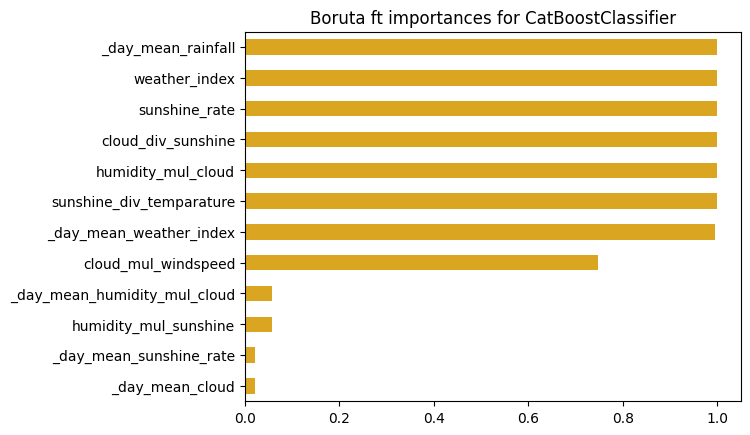

In [16]:
estimator = CatBoostClassifier(
    iterations=100,
    learning_rate=0.1,
    depth=4,
    random_state=19,
    verbose=False,
    allow_writing_files=False,
)
model = checkup(estimator, X, y, folds=7)
importances = boruta(X, y, estimator.copy(), seed=10, plot=True, alpha=0.99)

In [93]:
# estimator = LGBMClassifier(
#     n_estimators=50,
#     learning_rate=0.025,
#     max_depth=4,
#     random_state=19,
#     verbose=-1
# )
# model = checkup(estimator, X, y, folds=7)
# importances = boruta(X, y, deepcopy(estimator), seed=10, plot=True, alpha=0.99)

__submission__

In [92]:
# base
T = pipes['base'].transform(test.drop(columns='rainfall'))
rainfall = model.predict_proba(T)[:, 1]

if (test['rainfall'] != rainfall).any():
    test['rainfall'] = rainfall
    test.reset_index()[['id', 'rainfall']].to_csv(f'{uuid.uuid4().hex}.csv', index=False)

In [104]:
# SGD
T = pipes['sgd'].transform(test.drop(columns='rainfall'))
rainfall = model.predict_proba(T)[:, 1]

if (test['rainfall'] != rainfall).any():
    test['rainfall'] = rainfall
    test.reset_index()[['id', 'rainfall']].to_csv(f'{uuid.uuid4().hex}.csv', index=False)

__NN approach__

In [373]:
import torch
import torch.optim as opt
import torch.utils.data
from tqdm import tqdm

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
DEVICE

'cuda'

In [383]:
class Dataset(torch.utils.data.Dataset):
    def __init__(self, X, y = None, size: int = 3):
        self.x = X.values.reshape(*X.shape, 1)
        self.y = y.values.reshape(-1, 1) if y is not None else None
        self.size = size

    def __getitem__(self, index):
        """Return item with N previous items"""
        x_bundle, y_bundle = [], []
        for step in range(self.size):
            if (idx := index - step) < 0:
                idx = index
            x_bundle.append(torch.as_tensor(self.x[idx], dtype=torch.float32))
        return (
            torch.concat(x_bundle, dim=-1),
            torch.as_tensor(self.y[index], dtype=torch.float32) if self.y is not None else None
        )
        # return (
        #     torch.as_tensor(self.x[index], dtype=torch.float32),
        #     torch.as_tensor(self.y[index], dtype=torch.float32)
        # )

    def __len__(self):
        return self.x.shape[0]

dataset = Dataset(SGD_X, y, size=3)

In [445]:
class Model:
    def __init__(
            self,
            in_channels: int,
            backdays: int,
            hidden_channels: int = 128,
            criterion: torch.nn.modules.loss._Loss = torch.nn.BCELoss(),
            optimizer: type[torch.optim.Optimizer] = opt.Adam,
            device: Literal['cpu', 'cuda'] = 'cpu',
            **optimizer_params
    ):
        self.device = device
        self.backdays = backdays
        CHANNELS = hidden_channels
        self.model = torch.nn.Sequential(
            # torch.nn.Flatten(1),
            # torch.nn.LazyLinear(6 * CHANNELS * backdays),
            # torch.nn.ReLU(),
            # torch.nn.Unflatten(1, (6 * CHANNELS, backdays)),

            # torch.nn.Conv1d(6 * CHANNELS, 3 * CHANNELS, kernel_size=backdays, groups=3),
            torch.nn.Conv1d(in_channels, 3 * CHANNELS, kernel_size=backdays, groups=1),
            torch.nn.ReLU(),
            torch.nn.MaxPool1d(kernel_size=2, padding=1),
            torch.nn.Dropout(0.2),

            torch.nn.Conv1d(3 * CHANNELS, 2 * CHANNELS, kernel_size=2, padding=1),
            torch.nn.ReLU(),
            torch.nn.MaxPool1d(kernel_size=2),
            torch.nn.Flatten(1),

            torch.nn.Linear(2 * CHANNELS, 64),
            torch.nn.ReLU(),
            torch.nn.Dropout(0.2),
            torch.nn.Linear(64, 32),
            torch.nn.ReLU(),
            torch.nn.Linear(32, 1),
            torch.nn.Sigmoid(),
        )
        self.model.compile()
        self.optimizer = optimizer(self.model.parameters(), **optimizer_params)
        self.criterion = criterion

    def fit(self, X, y, epochs: int = 5, batch_size: int = 32, verbose: bool = True):
        # make dataset loader
        dataset = Dataset(X, y, size=self.backdays)
        loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size)
        # fit
        self.model.to(self.device)
        self.model.train()
        for ep in range(epochs):
            sum_loss, items = 0.0, 0
            if verbose:
                pbar = tqdm(enumerate(loader), total=len(loader), desc=f'Epoch {ep + 1}/{epochs}')
            else:
                pbar = enumerate(loader)
            for i, batch in pbar:
                inputs, labels = batch[0].to(self.device), batch[1].to(self.device)
                self.optimizer.zero_grad()
                outputs = self.model(inputs)
                loss = self.criterion(outputs, labels)
                loss.backward()
                self.optimizer.step()
                # calc loss
                sum_loss += loss.item()
                items += len(labels)
                if verbose and isinstance(pbar, tqdm):
                    pbar.set_postfix({'cumulative loss per item': sum_loss / items})
        self.model.eval()

    def predict_proba(self, X):
        assert self.model is not None, 'Model is not trained'
        # make dataset loader
        dataset = Dataset(X, y, size=self.backdays)
        loader = torch.utils.data.DataLoader(dataset, batch_size=X.shape[0])
        predictions = self.model.forward(next(iter(loader))[0])
        return predictions.detach()

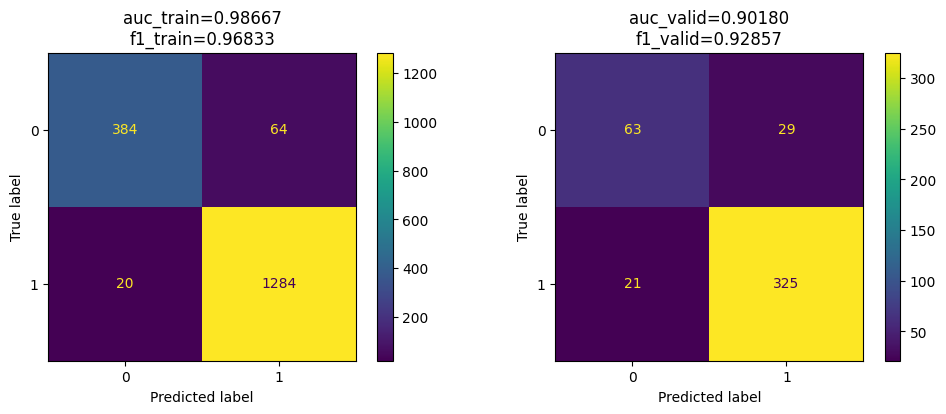

In [486]:
torch.manual_seed(11)
BACKDAYS = 3
dataset = Dataset(SGD_X, y, size=BACKDAYS)

model = Model(
    in_channels=SGD_X.shape[1],
    hidden_channels=32,
    backdays=BACKDAYS,
    criterion=torch.nn.BCELoss(),
    lr=0.01,
)
X_train, X_valid, y_train, y_valid = train_test_split(SGD_X, y, test_size=0.2, shuffle=False, random_state=19)
model.fit(X_train, y_train, epochs=50, batch_size=1024, verbose=False)

# predicting
y_pred_train = model.predict_proba(X_train)
y_pred_valid = model.predict_proba(X_valid)
# scoring
auc_train = roc_auc_score(y_train, y_pred_train)
auc_valid = roc_auc_score(y_valid, y_pred_valid)
f1_train = f1_score(y_train, y_pred_train > 0.5)
f1_valid = f1_score(y_valid, y_pred_valid > 0.5)
# drawing
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ConfusionMatrixDisplay.from_predictions(y_train, y_pred_train.numpy() > 0.5, ax=ax[0])
ConfusionMatrixDisplay.from_predictions(y_valid, y_pred_valid.numpy() > 0.5, ax=ax[1])
ax[0].set_title(f'{auc_train=:.5f}\n{f1_train=:.5f}')
ax[1].set_title(f'{auc_valid=:.5f}\n{f1_valid=:.5f}')
plt.show()

__NN cross validation__

In [487]:
def nn_checkup(estimator_base, X, y, folds=7, **fit_params):
    metrics = []
    kf = StratifiedKFold(n_splits=folds, shuffle=True, random_state=19)
    estimator = estimator_base
    for f, (train, valid) in enumerate(kf.split(X, y)):
        estimator = deepcopy(estimator_base)
        estimator.fit(X.loc[train], y[train], **fit_params)

        pt = estimator.predict_proba(X.loc[train]).numpy()
        pv = estimator.predict_proba(X.loc[valid]).numpy()

        auc_train = roc_auc_score(y[train], pt)
        auc_valid = roc_auc_score(y[valid], pv)
        f1_train = f1_score(y[train], pt > 0.5)
        f1_valid = f1_score(y[valid], pv > 0.5)
        metrics.append((auc_train, f1_train, auc_valid, f1_valid))
        print(f'Fold: {f}; TRAIN ROC AUC={auc_train:.5f}; TRAIN f1={f1_train:.5f} | VALID ROC AUC={auc_valid:.5f}; VALID f1={f1_valid:.5f}')
    means = np.mean(metrics, axis=0)
    print(f'MEAN: TRAIN ROC AUC={means[0]:.5f}; TRAIN f1={means[1]:.5f} | VALID ROC AUC={means[2]:.5f}; VALID f1={means[3]:.5f}')
    return estimator


torch.manual_seed(11)
_ = nn_checkup(model, SGD_X, y, epochs=10, batch_size=512, verbose=False)

Fold: 0; TRAIN ROC AUC=0.98398; TRAIN f1=0.96134 | VALID ROC AUC=0.92340; VALID f1=0.93528
Fold: 1; TRAIN ROC AUC=0.98201; TRAIN f1=0.96470 | VALID ROC AUC=0.92615; VALID f1=0.90987
Fold: 2; TRAIN ROC AUC=0.98495; TRAIN f1=0.96195 | VALID ROC AUC=0.91085; VALID f1=0.92181
Fold: 3; TRAIN ROC AUC=0.98088; TRAIN f1=0.96545 | VALID ROC AUC=0.91140; VALID f1=0.92813
Fold: 4; TRAIN ROC AUC=0.98556; TRAIN f1=0.96894 | VALID ROC AUC=0.93396; VALID f1=0.93139
Fold: 5; TRAIN ROC AUC=0.98746; TRAIN f1=0.96388 | VALID ROC AUC=0.90611; VALID f1=0.92562
Fold: 6; TRAIN ROC AUC=0.98395; TRAIN f1=0.96154 | VALID ROC AUC=0.92539; VALID f1=0.93168
MEAN: TRAIN ROC AUC=0.98411; TRAIN f1=0.96397 | VALID ROC AUC=0.91961; VALID f1=0.92625


__final fit__

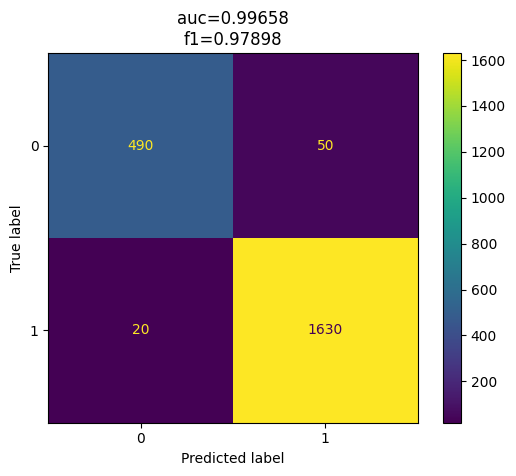

In [489]:
torch.manual_seed(11)
BACKDAYS = 3
dataset = Dataset(SGD_X, y, size=BACKDAYS)

model = Model(
    in_channels=SGD_X.shape[1],
    hidden_channels=32,
    backdays=BACKDAYS,
    criterion=torch.nn.BCELoss(),
    lr=0.01,
)
model.fit(SGD_X, y, epochs=100, batch_size=1024, verbose=False)

predictions = model.predict_proba(SGD_X)
auc = roc_auc_score(y, predictions)
f1 = f1_score(y, predictions > 0.5)
fix, ax = plt.subplots(1, 1)
ConfusionMatrixDisplay.from_predictions(y, predictions.numpy() > 0.5, ax=ax)
ax.set_title(f'{auc=:.5f}\n{f1=:.5f}')
plt.show()

In [490]:
# CNN
T = pipes['sgd'].transform(test.drop(columns='rainfall'))
rainfall = model.predict_proba(T)

if (test['rainfall'] != rainfall).any():
    filecode = uuid.uuid4().hex
    test['rainfall'] = rainfall
    test.reset_index()[['id', 'rainfall']].to_csv(f'{filecode}.csv', index=False)
    print(filecode)

e931842e758a4319bce56676ab686d31


In [ ]:
#